Task 1 :

In [1]:
import os
import zipfile
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
# Unzip the dataset
def unzip_dataset(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Dataset unzipped to {extract_to}")

In [3]:
# load and preprocess the images
def preprocess_images(folder_path, image_size):
    images = []
    labels = []

    for user_folder in os.listdir(folder_path):
        user_path = os.path.join(folder_path, user_folder)
        if os.path.isdir(user_path):  
            label = user_folder  
            for img_file in os.listdir(user_path):
                img_path = os.path.join(user_path, img_file)
                try:
                    
                    img = Image.open(img_path).convert('L')
                    img = img.resize(image_size)
                    img_array = np.array(img) / 255.0  
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error processing image {img_path}: {e}")

    return np.array(images), np.array(labels)

In [4]:
# Encode labels
def encode_labels(labels):
    unique_labels = sorted(set(labels))
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    encoded_labels = np.array([label_to_index[label] for label in labels])
    return encoded_labels, label_to_index

In [5]:
# Split dataset into training and testing set
def split_dataset(images, labels, test_size=0.2):
    
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels, test_size=test_size, random_state=42
    )
    return X_train, X_test, y_train, y_test

In [6]:
image_size = (256, 128)  # Resize images

dataset_folder = os.path.join("/kaggle/input/isolated-words-peruser/isolated_words_per_user")
images, labels = preprocess_images(dataset_folder, image_size)

# Encode labels
labels_encoded, label_to_index = encode_labels(labels)

# Split dataset
X_train, X_test, y_train, y_test = split_dataset(images, labels_encoded)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")
print(f"Label mapping: {label_to_index}")

Training set: (6515, 128, 256), (6515,)
Test set: (1629, 128, 256), (1629,)
Label mapping: {'user001': 0, 'user002': 1, 'user003': 2, 'user004': 3, 'user005': 4, 'user006': 5, 'user007': 6, 'user008': 7, 'user009': 8, 'user010': 9, 'user011': 10, 'user012': 11, 'user013': 12, 'user014': 13, 'user015': 14, 'user016': 15, 'user017': 16, 'user018': 17, 'user019': 18, 'user020': 19, 'user021': 20, 'user022': 21, 'user023': 22, 'user024': 23, 'user025': 24, 'user026': 25, 'user027': 26, 'user028': 27, 'user029': 28, 'user030': 29, 'user031': 30, 'user032': 31, 'user033': 32, 'user034': 33, 'user035': 34, 'user036': 35, 'user037': 36, 'user038': 37, 'user039': 38, 'user040': 39, 'user041': 40, 'user042': 41, 'user043': 42, 'user044': 43, 'user045': 44, 'user046': 45, 'user047': 46, 'user048': 47, 'user049': 48, 'user050': 49, 'user051': 50, 'user052': 51, 'user053': 52, 'user054': 53, 'user055': 54, 'user056': 55, 'user057': 56, 'user058': 57, 'user059': 58, 'user060': 59, 'user061': 60, 'us

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def create_cnn_model_v3(input_shape=(256, 128, 1),  
                        num_classes=82,
                        num_filters=[32, 64, 128],  
                        kernel_size=(3, 3),
                        pool_size=(3, 3),
                        dropout_rate=0.25,
                        learning_rate=0.0001):  

    model = Sequential()

    for i, filters in enumerate(num_filters):
        if i == 0:
            model.add(Conv2D(filters=filters, kernel_size=kernel_size, strides=(1, 1),
                             padding='same', activation='relu', input_shape=input_shape))
        else:
            model.add(Conv2D(filters=filters, kernel_size=kernel_size, strides=(1, 1),
                             padding='same', activation='relu'))

        
        model.add(BatchNormalization())

        
        model.add(AveragePooling2D(pool_size=pool_size))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))

    model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

cnn_model_v3 = create_cnn_model_v3()
cnn_model_v3.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 256, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_3                  │ (None, 85, 42, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 85, 42, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 85, 42, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_4                  │ (None, 28, 14, 64)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 28, 14, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_5                  │ (None, 9, 4, 128)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 82)                  │          10,578 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 694,098 (2.65 MB)

 Trainable params: 693,650 (2.65 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
X_train = X_train.reshape(-1, 256, 128, 1)  
X_test = X_test.reshape(-1, 256, 128, 1)

In [ ]:
# Train the CNN model
history = cnn_model_v3.fit(
    X_train, y_train,
    epochs=20,  
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=2
)

Epoch 1/20
204/204 - 5s - 24ms/step - accuracy: 0.7607 - loss: 0.9014 - val_accuracy: 0.3947 - val_loss: 2.2693
Epoch 2/20
204/204 - 4s - 18ms/step - accuracy: 0.7773 - loss: 0.8359 - val_accuracy: 0.3456 - val_loss: 2.4356
Epoch 3/20
204/204 - 4s - 18ms/step - accuracy: 0.7922 - loss: 0.7807 - val_accuracy: 0.1271 - val_loss: 6.4368
Epoch 4/20
204/204 - 4s - 19ms/step - accuracy: 0.8166 - loss: 0.7082 - val_accuracy: 0.1799 - val_loss: 3.8384
Epoch 5/20
204/204 - 4s - 19ms/step - accuracy: 0.8362 - loss: 0.6463 - val_accuracy: 0.2732 - val_loss: 3.4650
Epoch 6/20
204/204 - 5s - 25ms/step - accuracy: 0.8517 - loss: 0.5936 - val_accuracy: 0.3628 - val_loss: 2.4877
Epoch 7/20
204/204 - 5s - 26ms/step - accuracy: 0.8626 - loss: 0.5499 - val_accuracy: 0.1645 - val_loss: 5.0737
Epoch 8/20
204/204 - 5s - 24ms/step - accuracy: 0.8817 - loss: 0.4938 - val_accuracy: 0.2179 - val_loss: 5.0560
Epoch 9/20
204/204 - 5s - 25ms/step - accuracy: 0.8965 - loss: 0.4441 - val_accuracy: 0.1166 - val_loss:

In [ ]:
test_loss, test_accuracy = cnn_model_v3.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 21.36%


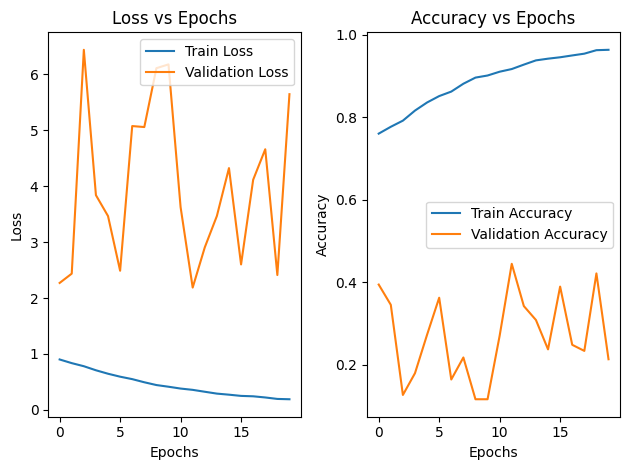

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def create_cnn_model_v4(input_shape=(256, 128, 1),
                        num_classes=82,
                        num_filters=[32, 64, 128, 256],  
                        kernel_size=(3, 3),
                        pool_size=(2, 2),  
                        dropout_rate=0.3,  
                        learning_rate=0.0001):

    model = Sequential()

    for i, filters in enumerate(num_filters):
        if i == 0:
            model.add(Conv2D(filters=filters, kernel_size=kernel_size, padding='same', activation='relu', input_shape=input_shape))
        else:
            model.add(Conv2D(filters=filters, kernel_size=kernel_size, padding='same', activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=pool_size))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

cnn_model_v4 = create_cnn_model_v4()
cnn_model_v4.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 256, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 256, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 64, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 128, 64, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 128, 64, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 64, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 64, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 64, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 32, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 32, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 32, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 8, 256)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │       8,388,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 82)                  │          21,074 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,799,698 (33.57 MB)

 Trainable params: 8,798,738 (33.56 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = cnn_model_v4.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,  # Train for more epochs
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

test_loss, test_accuracy = cnn_model_v4.evaluate(X_test, y_test, verbose=0)
print(f"Enhanced Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/30
204/204 - 33s - 163ms/step - accuracy: 0.0348 - loss: 4.3905 - val_accuracy: 0.0135 - val_loss: 8.7522 - learning_rate: 1.0000e-04
Epoch 2/30
204/204 - 19s - 91ms/step - accuracy: 0.0629 - loss: 4.1347 - val_accuracy: 0.0190 - val_loss: 4.6747 - learning_rate: 1.0000e-04
Epoch 3/30
204/204 - 9s - 44ms/step - accuracy: 0.0939 - loss: 3.9270 - val_accuracy: 0.0798 - val_loss: 4.0556 - learning_rate: 1.0000e-04
Epoch 4/30
204/204 - 9s - 46ms/step - accuracy: 0.1394 - loss: 3.6372 - val_accuracy: 0.1246 - val_loss: 3.8296 - learning_rate: 1.0000e-04
Epoch 5/30
204/204 - 10s - 51ms/step - accuracy: 0.2057 - loss: 3.2601 - val_accuracy: 0.1565 - val_loss: 3.7237 - learning_rate: 1.0000e-04
Epoch 6/30
204/204 - 10s - 50ms/step - accuracy: 0.2818 - loss: 2.8145 - val_accuracy: 0.1731 - val_loss: 3.5905 - learning_rate: 1.0000e-04
Epoch 7/30
204/204 - 10s - 50ms/step - accuracy: 0.4040 - loss: 2.2967 - val_accuracy: 0.0626 - val_loss: 6.3007 - learning_rate: 1.0000e-04
Epoch 8/30
204

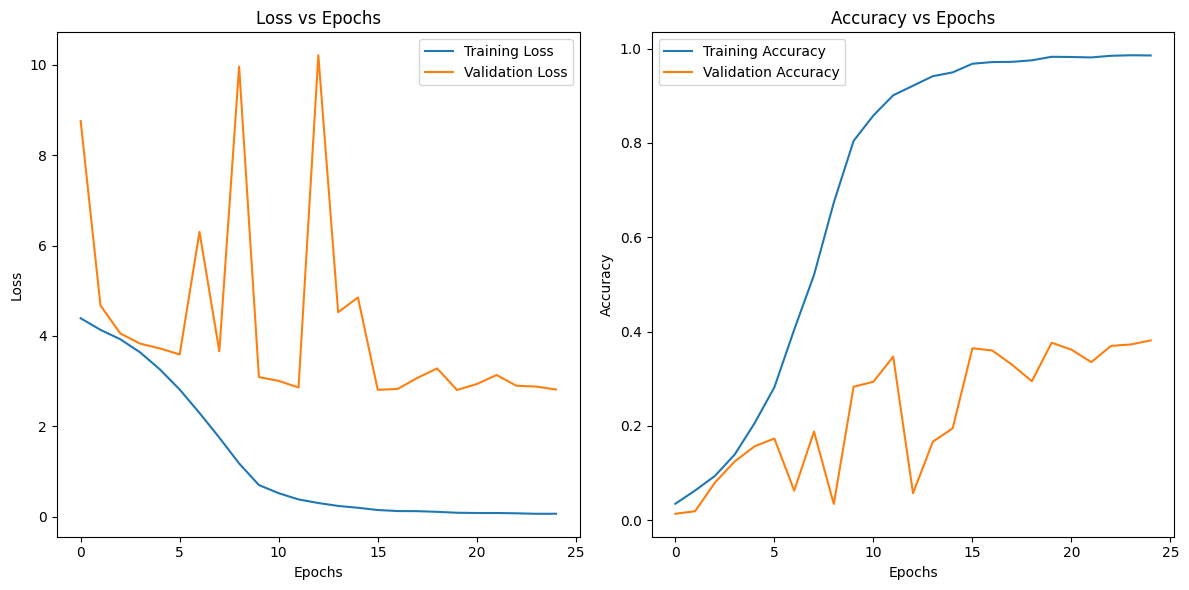

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

def create_cnn_model_v5(input_shape=(256, 128, 1),
                        num_classes=82,
                        num_filters=[32, 64, 128, 256, 512],  
                        kernel_size=(3, 3),
                        pool_size=(2, 2),  
                        dropout_rate=0.4,  
                        learning_rate=0.00001,
                        l2_reg=0.01):  

    model = Sequential()

    for i, filters in enumerate(num_filters):
        if i == 0:
            model.add(Conv2D(filters=filters, kernel_size=kernel_size, padding='same',
                             activation='relu', input_shape=input_shape, kernel_regularizer=l2(l2_reg)))
        else:
            model.add(Conv2D(filters=filters, kernel_size=kernel_size, padding='same',
                             activation='relu', kernel_regularizer=l2(l2_reg)))

        model.add(BatchNormalization())

        model.add(MaxPooling2D(pool_size=pool_size))

    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(512, activation='relu', kernel_regularizer=l2(l2_reg)))  
    model.add(Dropout(dropout_rate))  # Regularization

    model.add(Dense(256, activation='relu', kernel_regularizer=l2(l2_reg))) 
    model.add(Dropout(dropout_rate))  

    # Output layer
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

cnn_model_v5 = create_cnn_model_v5()
cnn_model_v5.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 64, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 64, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128, 64, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 64, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 32, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 8, 256)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 8, 512)          │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 16, 8, 512)          │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       8,389,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,3

 Total params: 10,113,490 (38.58 MB)

 Trainable params: 10,111,506 (38.57 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = cnn_model_v5.fit(
    X_train, y_train,
    batch_size=32,
    epochs=75,  # Train for more epochs
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

test_loss, test_accuracy = cnn_model_v5.evaluate(X_test, y_test, verbose=0)
print(f"Enhanced Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/75
204/204 - 31s - 153ms/step - accuracy: 0.0190 - loss: 24.5083 - val_accuracy: 0.0092 - val_loss: 24.2257 - learning_rate: 1.0000e-05
Epoch 2/75
204/204 - 23s - 114ms/step - accuracy: 0.0313 - loss: 23.8317 - val_accuracy: 0.0233 - val_loss: 23.8252 - learning_rate: 1.0000e-05
Epoch 3/75
204/204 - 10s - 50ms/step - accuracy: 0.0434 - loss: 23.4864 - val_accuracy: 0.0540 - val_loss: 23.2928 - learning_rate: 1.0000e-05
Epoch 4/75
204/204 - 9s - 44ms/step - accuracy: 0.0637 - loss: 23.1275 - val_accuracy: 0.0909 - val_loss: 22.8866 - learning_rate: 1.0000e-05
Epoch 5/75
204/204 - 9s - 44ms/step - accuracy: 0.0784 - loss: 22.7501 - val_accuracy: 0.1191 - val_loss: 22.5254 - learning_rate: 1.0000e-05
Epoch 6/75
204/204 - 9s - 44ms/step - accuracy: 0.0915 - loss: 22.3798 - val_accuracy: 0.1400 - val_loss: 22.1309 - learning_rate: 1.0000e-05
Epoch 7/75
204/204 - 10s - 50ms/step - accuracy: 0.1205 - loss: 21.9736 - val_accuracy: 0.1608 - val_loss: 21.7700 - learning_rate: 1.0000e-05


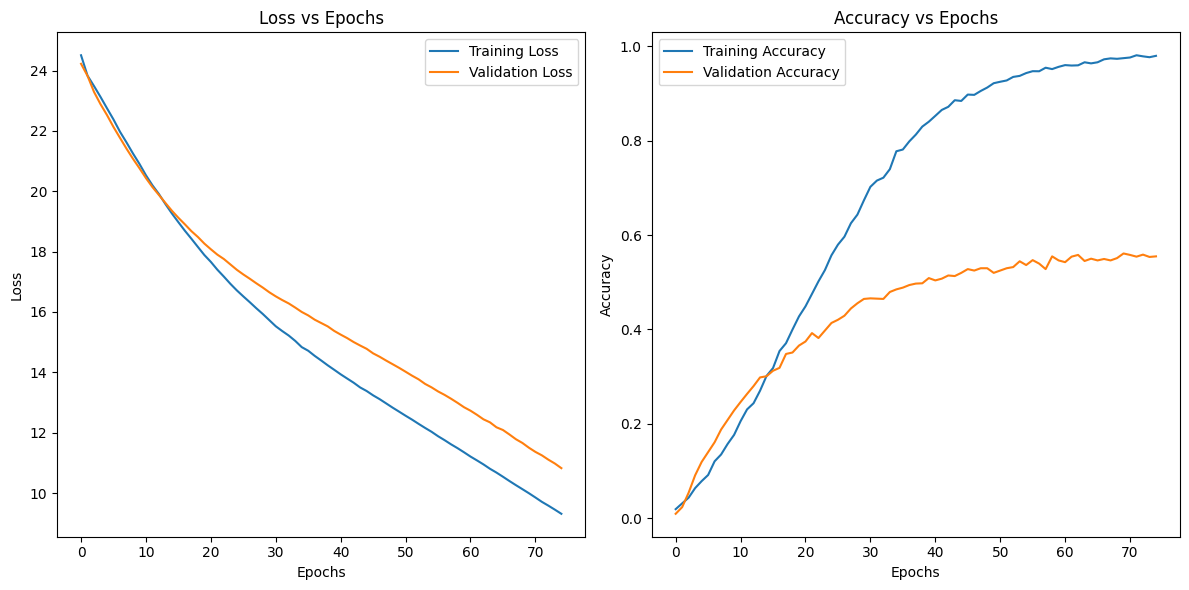

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Task 2:

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

augmentor = ImageDataGenerator(
    rotation_range=15,  
    zoom_range=0.1,  
    width_shift_range=0.1,  
    height_shift_range=0.1,  
)

def combined_data_generator(X_train, y_train, batch_size, augmentor):
    while True:  
        indices = np.arange(len(X_train))
        np.random.shuffle(indices)  
        for i in range(0, len(X_train), batch_size // 2):
            batch_indices = indices[i:i + (batch_size // 2)]

            original_images = X_train[batch_indices]
            original_labels = y_train[batch_indices]

            aug_iter = augmentor.flow(
                original_images[..., np.newaxis],  
                original_labels,
                batch_size=batch_size // 2,
                shuffle=False
            )
            augmented_images, augmented_labels = next(aug_iter)

            # Combine original and augmented data
            combined_images = np.concatenate((original_images[..., np.newaxis], augmented_images))
            combined_labels = np.concatenate((original_labels, augmented_labels))

            yield combined_images, combined_labels


In [ ]:
batch_size = 32

train_gen = combined_data_generator(X_train, y_train, batch_size, augmentor)


In [ ]:
cnn_model_v5_combined = create_cnn_model_v5()

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

steps_per_epoch = len(X_train) // (batch_size // 2)

history_combined = cnn_model_v5_combined.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,  
    epochs=50,
    validation_data=(X_test[..., np.newaxis], y_test),  
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)


Epoch 1/50
407/407 - 50s - 124ms/step - accuracy: 0.0184 - loss: 24.2441 - val_accuracy: 0.0147 - val_loss: 23.8279 - learning_rate: 1.0000e-05
Epoch 2/50
407/407 - 31s - 77ms/step - accuracy: 0.0284 - loss: 23.4503 - val_accuracy: 0.0559 - val_loss: 23.0553 - learning_rate: 1.0000e-05
Epoch 3/50
407/407 - 23s - 57ms/step - accuracy: 0.0361 - loss: 22.7882 - val_accuracy: 0.0761 - val_loss: 22.3211 - learning_rate: 1.0000e-05
Epoch 4/50
407/407 - 24s - 60ms/step - accuracy: 0.0445 - loss: 22.0657 - val_accuracy: 0.0823 - val_loss: 21.5553 - learning_rate: 1.0000e-05
Epoch 5/50
407/407 - 23s - 58ms/step - accuracy: 0.0545 - loss: 21.3037 - val_accuracy: 0.1142 - val_loss: 20.7315 - learning_rate: 1.0000e-05
Epoch 6/50
407/407 - 24s - 59ms/step - accuracy: 0.0688 - loss: 20.5459 - val_accuracy: 0.1467 - val_loss: 19.9188 - learning_rate: 1.0000e-05
Epoch 7/50
407/407 - 24s - 58ms/step - accuracy: 0.0823 - loss: 19.7948 - val_accuracy: 0.1559 - val_loss: 19.1688 - learning_rate: 1.0000e-0

In [ ]:
test_loss_combined, test_accuracy_combined = cnn_model_v5_combined.evaluate(X_test[..., np.newaxis], y_test, verbose=0)
print(f"Test Accuracy with Combined Dataset: {test_accuracy_combined * 100:.2f}%")


Test Accuracy with Combined Dataset: 72.74%


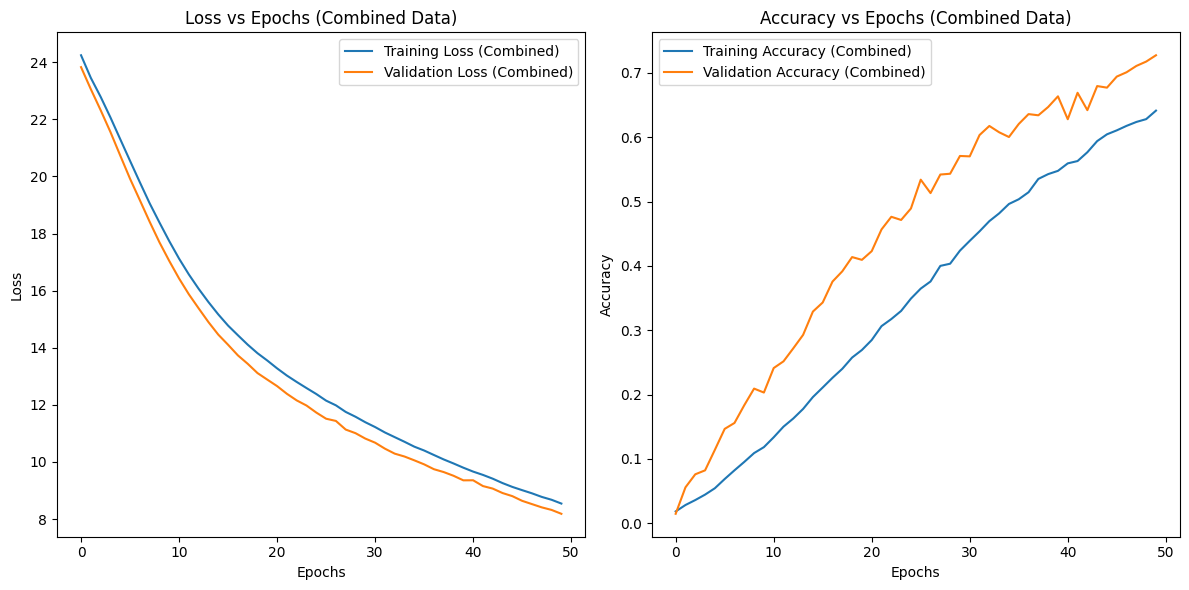

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_combined.history['loss'], label='Training Loss (Combined)')
plt.plot(history_combined.history['val_loss'], label='Validation Loss (Combined)')
plt.title('Loss vs Epochs (Combined Data)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_combined.history['accuracy'], label='Training Accuracy (Combined)')
plt.plot(history_combined.history['val_accuracy'], label='Validation Accuracy (Combined)')
plt.title('Accuracy vs Epochs (Combined Data)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Task 3:

In [ ]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
image_size = (128, 256)
X_train_resized = np.array([np.array(Image.fromarray(img).resize(image_size)) for img in X_train])
X_test_resized = np.array([np.array(Image.fromarray(img).resize(image_size)) for img in X_test])

X_train_rgb = np.repeat(X_train_resized[..., np.newaxis], 3, axis=-1)
X_test_rgb = np.repeat(X_test_resized[..., np.newaxis], 3, axis=-1)

print(f"Training data shape: {X_train_rgb.shape}, Test data shape: {X_test_rgb.shape}")


In [ ]:
augmentor = ImageDataGenerator(
    rotation_range=15,       
    zoom_range=0.1,         
    width_shift_range=0.1,   
    height_shift_range=0.1,      
)

batch_size = 32
train_gen = augmentor.flow(X_train_rgb, y_train, batch_size=batch_size)


In [23]:
# Build the ResNet50V2 model
def build_resnet50v2(input_shape=(256, 128, 3), num_classes=82):
    resnet_base = ResNet50V2(weights=None, include_top=False, input_tensor=Input(shape=input_shape))

    x = resnet_base.output
    x = GlobalAveragePooling2D()(x)  
    x = Dropout(0.5)(x)              
    x = Dense(256, activation='relu')(x)  
    x = Dropout(0.5)(x)             
    output = Dense(num_classes, activation='softmax')(x)  

    model = Model(inputs=resnet_base.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


resnet50v2_model = build_resnet50v2()
resnet50v2_model.summary()


In [24]:
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6)

history = model.fit(
    train_gen,
    steps_per_epoch=len(X_train_rgb) // batch_size,
    epochs=50,  
    validation_data=(X_test_rgb, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

test_loss, test_accuracy = model.evaluate(X_test_rgb, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/50
203/203 - 61s - 299ms/step - accuracy: 0.0578 - loss: 4.1400 - val_accuracy: 0.0448 - val_loss: 7.4507 - learning_rate: 0.0010
Epoch 2/50
203/203 - 22s - 110ms/step - accuracy: 0.1399 - loss: 3.4417 - val_accuracy: 0.0804 - val_loss: 4.7133 - learning_rate: 0.0010
Epoch 3/50
203/203 - 22s - 108ms/step - accuracy: 0.2167 - loss: 2.9662 - val_accuracy: 0.0994 - val_loss: 4.9998 - learning_rate: 0.0010
Epoch 4/50
203/203 - 22s - 107ms/step - accuracy: 0.3119 - loss: 2.5664 - val_accuracy: 0.1676 - val_loss: 4.1005 - learning_rate: 0.0010
Epoch 5/50
203/203 - 21s - 104ms/step - accuracy: 0.3728 - loss: 2.2745 - val_accuracy: 0.2922 - val_loss: 2.9483 - learning_rate: 0.0010
Epoch 6/50
203/203 - 22s - 107ms/step - accuracy: 0.4152 - loss: 2.0579 - val_accuracy: 0.2548 - val_loss: 3.6728 - learning_rate: 0.0010
Epoch 7/50
203/203 - 22s - 107ms/step - accuracy: 0.4651 - loss: 1.8443 - val_accuracy: 0.3708 - val_loss: 2.7237 - learning_rate: 0.0010
Epoch 8/50
203/203 - 21s - 105ms/s

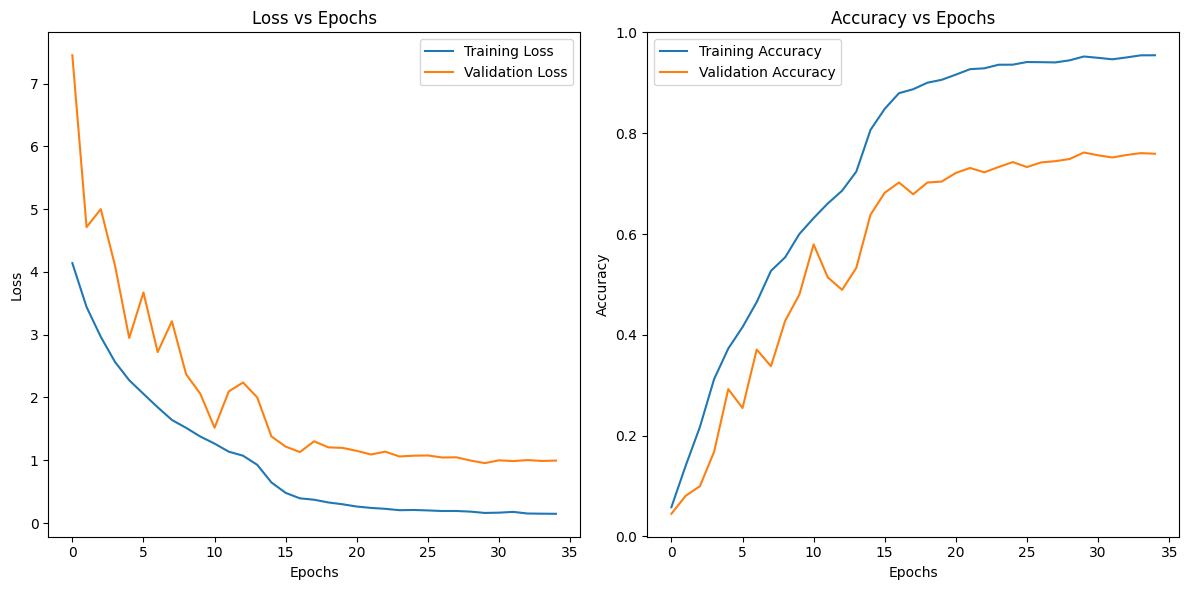

In [25]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import torch
from torch import nn, optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from PIL import Image

class CustomImageDataset(Dataset):
    def __init__(self, image_data, labels, transform=None):
        self.image_data = image_data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        image = Image.fromarray(self.image_data[idx])
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),  
    transforms.RandomHorizontalFlip(),  
    transforms.RandomRotation(20),  # Rotate images
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),  
    transforms.RandomResizedCrop(128, scale=(0.7, 1.0)),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def preprocess_images(folder_path):
    images, labels = [], []

    for user_folder in os.listdir(folder_path):
        user_path = os.path.join(folder_path, user_folder)
        if os.path.isdir(user_path):
            label = user_folder
            for img_file in os.listdir(user_path):
                img_path = os.path.join(user_path, img_file)
                try:
                    img = Image.open(img_path).convert('L')
                    img = img.resize((128, 128))  # Resize for consistency
                    img_array = np.array(img)
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")

    return np.array(images), np.array(labels)


def encode_labels(labels):
    unique_labels = sorted(set(labels))
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    encoded_labels = np.array([label_to_index[label] for label in labels])
    return encoded_labels, label_to_index


dataset_folder = "/kaggle/input/isolated-words-peruser/isolated_words_per_user"
images, labels = preprocess_images(dataset_folder)
labels_encoded, label_to_index = encode_labels(labels)

X_train, X_test, y_train, y_test = train_test_split(images, labels_encoded, test_size=0.2, random_state=42)

train_dataset = CustomImageDataset(X_train, y_train, transform=train_transform)
test_dataset = CustomImageDataset(X_test, y_test, transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  

for param in model.layer4.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
num_classes = len(label_to_index)
model.fc = nn.Sequential(
    nn.Dropout(0.5),  
    nn.Linear(num_features, num_classes)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

epochs = 30
best_val_accuracy = 0

for epoch in range(epochs):
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = 100 * correct / total
    scheduler.step()

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = 100 * val_correct / val_total
    print(f"Epoch {epoch+1}/{epochs}, Train Acc: {train_accuracy:.2f}%, Val Acc: {val_accuracy:.2f}%")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "best_model.pth")

print(f"Training complete. Best Validation Accuracy: {best_val_accuracy:.2f}%")

Task 4:

In [13]:
def preprocess_for_resnet(X):
    X_with_channels = X[..., np.newaxis]  
    X_resized = np.array([tf.image.resize(img, (128, 128)) for img in X_with_channels])
    X_rgb = np.repeat(X_resized, 3, axis=-1)  
    return X_rgb

In [14]:
def data_generator(X, y, batch_size, augmentor):
    generator = augmentor.flow(X, y, batch_size=batch_size, shuffle=True)
    while True:
        yield next(generator)

In [15]:
import tensorflow as tf

image_size = (256, 128)  


dataset_folder = os.path.join("/kaggle/input/isolated-words-peruser/isolated_words_per_user")
images, labels = preprocess_images(dataset_folder, image_size)

labels_encoded, label_to_index = encode_labels(labels)

X_train, X_test, y_train, y_test = split_dataset(images, labels_encoded)

X_train_rgb = preprocess_for_resnet(X_train)
X_test_rgb = preprocess_for_resnet(X_test)

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmentor = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
)

batch_size = 32  
train_gen = data_generator(X_train_rgb, y_train, batch_size, augmentor)

In [20]:
import os
import zipfile
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


resnet_base = ResNet50V2(
    weights="imagenet",  
    include_top=False,
    input_tensor=Input(shape=(128, 128, 3))  
)

# Freeze initial layers
for layer in resnet_base.layers[:100]:
    layer.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(len(np.unique(y_train)), activation="softmax")(x)

model = Model(inputs=resnet_base.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6)

history = model.fit(
    train_gen,
    steps_per_epoch=len(X_train_rgb) // batch_size,
    epochs=40,  
    validation_data=(X_test_rgb, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

test_loss, test_accuracy = model.evaluate(X_test_rgb, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/40
203/203 - 52s - 257ms/step - accuracy: 0.0337 - loss: 4.3475 - val_accuracy: 0.0798 - val_loss: 4.0588 - learning_rate: 1.0000e-04
Epoch 2/40
203/203 - 32s - 157ms/step - accuracy: 0.1217 - loss: 3.7850 - val_accuracy: 0.2112 - val_loss: 3.2060 - learning_rate: 1.0000e-04
Epoch 3/40
203/203 - 22s - 109ms/step - accuracy: 0.2619 - loss: 3.0103 - val_accuracy: 0.3419 - val_loss: 2.6041 - learning_rate: 1.0000e-04
Epoch 4/40
203/203 - 22s - 106ms/step - accuracy: 0.4046 - loss: 2.3293 - val_accuracy: 0.4856 - val_loss: 2.0719 - learning_rate: 1.0000e-04
Epoch 5/40
203/203 - 21s - 105ms/step - accuracy: 0.5371 - loss: 1.7461 - val_accuracy: 0.5592 - val_loss: 1.7162 - learning_rate: 1.0000e-04
Epoch 6/40
203/203 - 21s - 105ms/step - accuracy: 0.6520 - loss: 1.2883 - val_accuracy: 0.5777 - val_loss: 1.6260 - learning_rate: 1.0000e-04
Epoch 7/40
203/203 - 22s - 106ms/step - accuracy: 0.7222 - loss: 1.0192 - val_accuracy: 0.6108 - val_loss: 1.4886 - learning_rate: 1.0000e-04
Epoch 

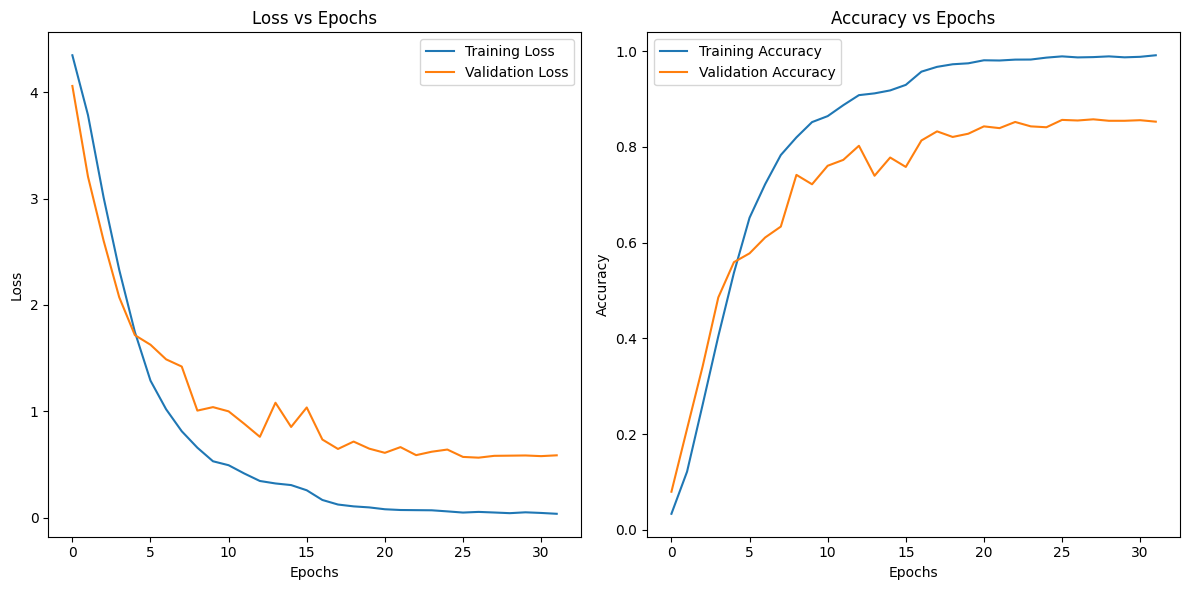

In [22]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()